In [ ]:
import pandas as pd 
import numpy as np
pd.set_option('display.width',1000)
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

In [2]:
df=pd.read_csv("dataset.csv")

#print(df.head(10))
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [3]:
X=df.iloc[:,[8,9,11,13,14,15,16,17,18]]
print(X)
print(X.columns)

        danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence    tempo
0              0.676  0.4610    -6.746       0.1430        0.0322          0.000001    0.3580   0.7150   87.917
1              0.420  0.1660   -17.235       0.0763        0.9240          0.000006    0.1010   0.2670   77.489
2              0.438  0.3590    -9.734       0.0557        0.2100          0.000000    0.1170   0.1200   76.332
3              0.266  0.0596   -18.515       0.0363        0.9050          0.000071    0.1320   0.1430  181.740
4              0.618  0.4430    -9.681       0.0526        0.4690          0.000000    0.0829   0.1670  119.949
...              ...     ...       ...          ...           ...               ...       ...      ...      ...
113995         0.172  0.2350   -16.393       0.0422        0.6400          0.928000    0.0863   0.0339  125.995
113996         0.174  0.1170   -18.318       0.0401        0.9940          0.976000    0.1050   0.0350  

In [4]:
# scaling
scaler=StandardScaler()
scaled_X=scaler.fit_transform(X)

scaled_X=pd.DataFrame(scaled_X, columns=X.columns)
print(scaled_X)

        danceability    energy  loudness  speechiness  acousticness  instrumentalness  liveness   valence     tempo
0           0.629244 -0.717148  0.300828     0.551848     -0.850202         -0.504109  0.758743  0.929306 -1.141863
1          -0.845908 -1.889980 -1.784744    -0.078993      1.831732         -0.504094 -0.591211 -0.798690 -1.489717
2          -0.742186 -1.122669 -0.293288    -0.273826     -0.315499         -0.504112 -0.507167 -1.365688 -1.528312
3          -1.733304 -2.312994 -2.039252    -0.457309      1.774593         -0.503883 -0.428376 -1.276974  1.987859
4           0.295030 -0.788711 -0.282750    -0.303145      0.463399         -0.504112 -0.686285 -1.184403 -0.073348
...              ...       ...       ...          ...           ...               ...       ...       ...       ...
113995     -2.274962 -1.615656 -1.617326    -0.401507      0.977652          2.493755 -0.668426 -1.697787  0.128333
113996     -2.263437 -2.084789 -2.000082    -0.421369      2.042245     

In [5]:
#outlier detection
for col in X:
    q3=X[col].quantile(0.75)
    q1=X[col].quantile(0.25)
    IQR=q3-q1
    outliers=X[(X[col]< q1- 1.5*IQR) |(X[col]> q3 +1.5*IQR)]
    pct=len(outliers)/(len(X))*100
    print(f"{col} : {pct:.2f} %")

danceability : 0.54 %
energy : 0.00 %
loudness : 5.41 %
speechiness : 11.59 %
acousticness : 0.00 %
instrumentalness : 22.15 %
liveness : 7.58 %
valence : 0.00 %
tempo : 0.54 %


In [6]:
# f1=[["speechiness","instrumentalness","time_signature"]]
# for feature in f1:
#     plt.boxplot(X[feature])
#     plt.title(f"{feature}")
#     plt.ylabel(f"{feature}")
#     plt.show()
    

cluster :2 | 24.340564325094935
cluster :3 | 18.138044322059386
cluster :4 | 19.11440302964829
cluster :5 | 18.903247691930943
cluster :6 | 19.589144604945815
cluster :7 | 20.402417151842062
cluster :8 | 20.6815668563549
cluster :9 | 18.693912875649964
cluster :10 | 17.367486979746463
cluster :11 | 17.418862172990877
cluster :12 | 16.19944288450286
cluster :13 | 15.910133805870942
cluster :14 | 15.961023458313203
cluster :15 | 15.241164466858068
cluster :16 | 15.366430464994355
cluster :17 | 14.054765459778999
cluster :18 | 14.108450271045776
cluster :19 | 13.48717865997088
cluster :20 | 13.60085389448155


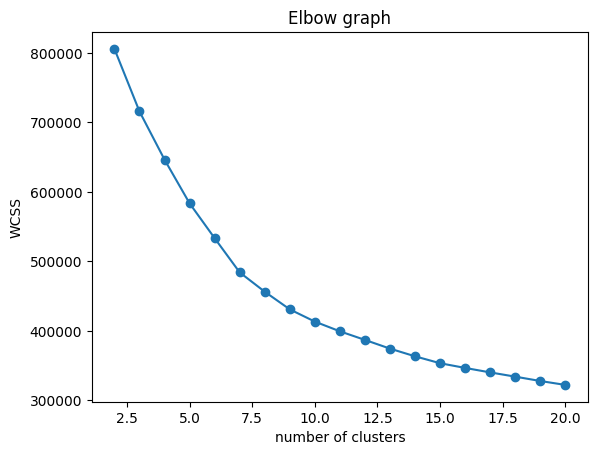

In [7]:
#elbow graph

wcss=[]
for i in range(2, 21):
    km=KMeans(n_clusters=i, n_init=10, random_state=42)
    label=km.fit_predict(scaled_X)
    wcss.append(km.inertia_)
    print(f"cluster :{i} | {silhouette_score(scaled_X, label,sample_size=1000, random_state=42)*100}")

plt.plot([i for i in range(2,21)],wcss, marker='o')

plt.title("Elbow graph")
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()
    


In [8]:
final_k = 4

final_model = KMeans(
    n_clusters=final_k,
    n_init=10,
    random_state=42
)

final_labels = final_model.fit_predict(scaled_X)

df["Cluster"] = final_labels

print(df["Cluster"].value_counts().sort_index())


Cluster
0     8730
1    47067
2    34832
3    23371
Name: count, dtype: int64


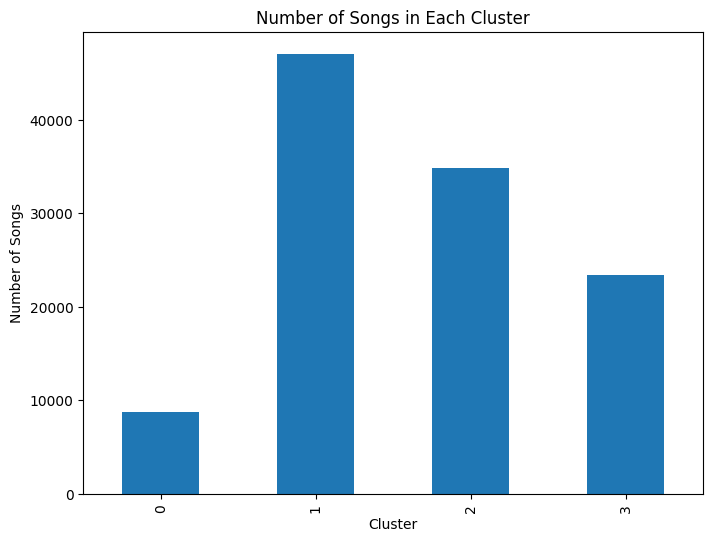

In [9]:
cluster_counts=df["Cluster"].value_counts().sort_index()
plt.figure(figsize=(8,6))
cluster_counts.plot(kind="bar")
plt.title("Number of Songs in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")

plt.show()

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(scaled_X)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)
print(X_pca[:,0])
print(X_pca[:,1])

Explained variance ratio:
[0.31928044 0.15850944]
Total explained variance: 0.477789879009825
[ 0.63956643 -3.33108483 -1.38750707 ... -1.13021357 -0.47015477
 -0.9834178 ]
[ 1.08183776  1.00964591 -0.20666656 ...  1.83029968  0.135089
  1.56622986]


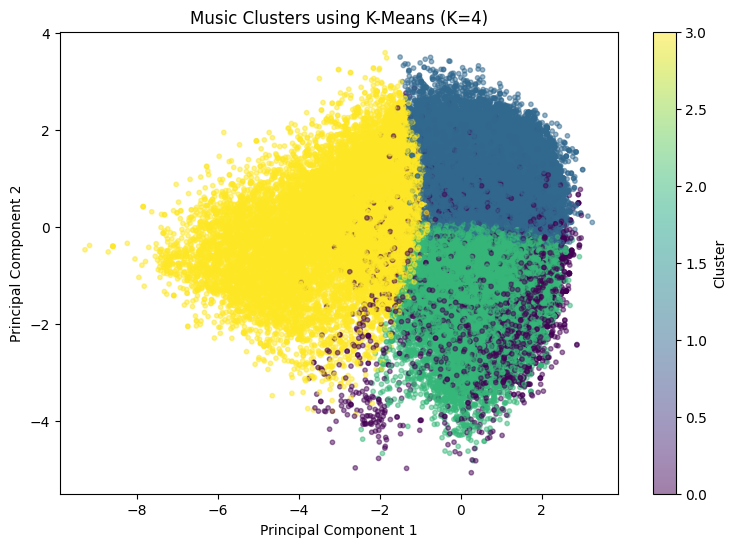

In [11]:
plt.figure(figsize=(9, 6))

plt.scatter(X_pca[:, 0],X_pca[:, 1],c=final_labels,s=10,alpha=0.5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(f"Music Clusters using K-Means (K={final_k})")

plt.colorbar(label="Cluster")

plt.show()

In [12]:
for cluster in sorted(df["Cluster"].unique()):

    print(f"\n========== CLUSTER {cluster} ==========")

    songs = df[df["Cluster"] == cluster]

    print(songs[["track_name", "artists", "track_genre"]].head(10))


========== CLUSTER 0 ==========
                                            track_name                    artists track_genre
51                                             透明だった世界              Motohiro Hata    acoustic
73                                You're Still The One                Bailey Jehl    acoustic
343                                   A Month from Now           Rail Yard Ghosts    acoustic
518                                              Waves                Canyon City    acoustic
535                                            Help Me    Sonny Boy Williamson II    acoustic
545  Unsteady - Acoustic Covers Versions of Popular...                SANNA NORTH    acoustic
549                                      Nickel Plated                   Get Dead    acoustic
598                           Days n Daze of Our Lives                Days N Daze    acoustic
685                                 Nine on the Bortle                Days N Daze    acoustic
696                        

In [16]:
song_name = "Bad Liar"

song_data = df[
    df["track_name"].str.lower() ==
    song_name.lower()
]

if len(song_data) == 0:

    print("Song not found.")

else:

    selected_cluster = song_data["Cluster"].iloc[0]

    recommendations = df[
        (df["Cluster"] == selected_cluster) &
        (df["track_name"] != song_data["track_name"].iloc[0])
    ]

    print(
        recommendations[
            ["track_name", "artists", "track_genre"]
        ].head(100)
    )

                     track_name                               artists track_genre
1              Ghost - Acoustic                          Ben Woodward    acoustic
2                To Begin Again                Ingrid Michaelson;ZAYN    acoustic
3    Can't Help Falling In Love                          Kina Grannis    acoustic
4                       Hold On                      Chord Overstreet    acoustic
6                 Say Something  A Great Big World;Christina Aguilera    acoustic
..                          ...                                   ...         ...
187            I Believe in You                             JJ Heller    acoustic
188                     At Home                            Jon Bryant    acoustic
189             Portland, Maine                         Donovan Woods    acoustic
190   Holding On and Letting Go                        Ross Copperman    acoustic
191                   The Flood                         Joshua Hyslop    acoustic

[100 rows x 3 c